# **Employee performance & Productivity Dataset**
## Summary
This dataset contains 100,000 rows of data capturing key aspects of employee performance, productivity, and demographics in a corporate environment. It includes details related to the employee's job, work habits, education, performance, and satisfaction. The dataset is designed for various purposes such as HR analytics, employee churn prediction, productivity analysis, and performance evaluation.
https://www.kaggle.com/datasets/mexwell/employee-performance-and-productivity-data
*****************************************

**Gender**: Gender of the employee (Male, Female, Other).

**Age**: Employee's age (between 22 and 60).

**Job_Title**: The role held by the employee (e.g., Manager, Analyst, Developer).

**Hire_Date**: The date the employee was hired.

**Years_At_Company**: The number of years the employee has been working for the company.

**Education_Level**: Highest educational qualification (High School, Bachelor, Master, PhD).

**Performance_Score**: Employee's performance rating (1 to 5 scale).

**Monthly_Salary**: The employee's monthly salary in USD, correlated with job title and performance score.

**Work_Hours_Per_Week**: Number of hours worked per week.

**Projects_Handled**: Total number of projects handled by the employee.

**Overtime_Hours**: Total overtime hours worked in the last year.

**Sick_Days**: Number of sick days taken by the employee.

**Remote_Work_Frequency**: Percentage of time worked remotely (0%, 25%, 50%, 75%, 100%).

**Team_Size**: Number of people in the employee's team.

**Training_Hours**: Number of hours spent in training.

**Promotions**: Number of promotions received during their tenure.

**Employee_Satisfaction_Score**: Employee satisfaction rating (1.0 to 5.0 scale).

**Resigned**: Boolean value indicating if the employee has resigned.

## **Data Upload And Library Import**

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Extended_Employee_Performance_and_Productivity_Data.csv to Extended_Employee_Performance_and_Productivity_Data.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')

In [5]:
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [6]:
df.tail()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
99995,99996,Finance,Male,27,Technician,2022-12-07 08:03:05.556036,1,Bachelor,4,4900.0,55,46,5,3,75,16,48,2,1.28,False
99996,99997,IT,Female,36,Consultant,2018-07-24 08:03:05.556036,6,Master,5,8250.0,39,35,7,0,0,10,77,1,3.48,True
99997,99998,Operations,Male,53,Analyst,2015-11-24 08:03:05.556036,8,High School,2,4800.0,31,13,6,5,0,5,87,1,2.60,False
99998,99999,HR,Female,22,Consultant,2015-08-03 08:03:05.556036,9,High School,5,8250.0,35,43,10,1,75,2,31,1,3.10,False
99999,100000,Finance,Female,43,Analyst,2024-03-04 08:03:05.556036,0,PhD,1,4400.0,51,43,27,11,75,13,45,1,2.64,False


In [7]:
df.isnull().sum()

,0
Employee_ID,0
Department,0
Gender,0
Age,0
Job_Title,0
Hire_Date,0
Years_At_Company,0
Education_Level,0
Performance_Score,0
Monthly_Salary,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

In [10]:
df = df.drop('Employee_ID', axis=1)

In [11]:
df = df.replace({'Resigned': {True: 1, False: 0}})
df['Resigned'] = df['Resigned'].astype(int)

In [12]:
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])
df['Hire_Year'] = df['Hire_Date'].dt.year
df['Hire_Month'] = df['Hire_Date'].dt.month
df = df.drop('Hire_Date', axis=1)
df['Hire_Month'] = pd.to_datetime(df['Hire_Month'], format='%m').dt.strftime('%b')

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns


# **Uni-Variate Analysis**
### **Numerical (Non-Visual & Visual)**


 ========== Age ==========
Mean 41.02941
Median 41.0
Min 22
Max 60
Std 11.244120657232344
Skew -0.006169658520242082
Kurtosis -1.2035279244627128
Var 126.4302493543991
Quantiles:
0.25    31.0
0.50    41.0
0.75    51.0
Name: Age, dtype: float64
IQR
20.0
MAD: 9.736787018200001


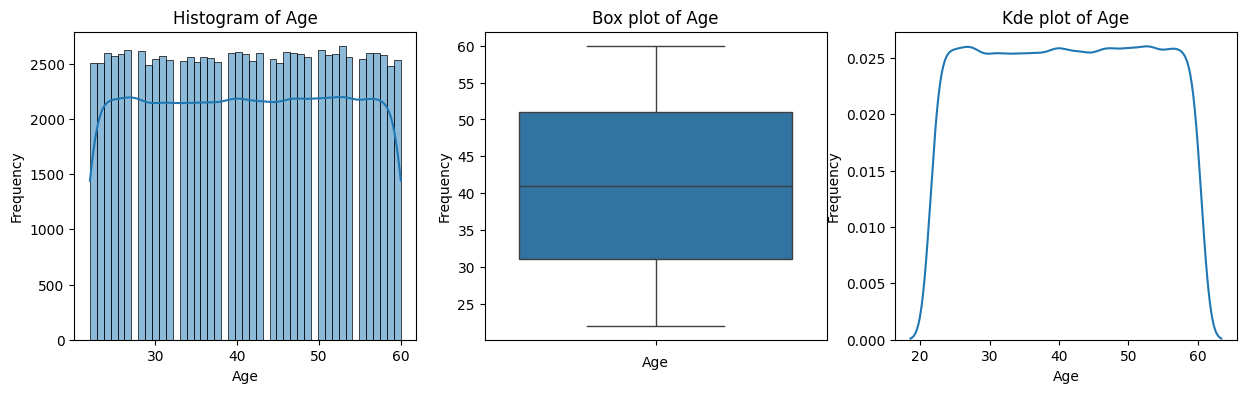


 ========== Years_At_Company ==========
Mean 4.47607
Median 4.0
Min 0
Max 10
Std 2.8693361054422226
Skew 0.011210732097285637
Kurtosis -1.2217186175125785
Var 8.233089685994342
Quantiles:
0.25    2.0
0.50    4.0
0.75    7.0
Name: Years_At_Company, dtype: float64
IQR
5.0
MAD: 2.4972832954


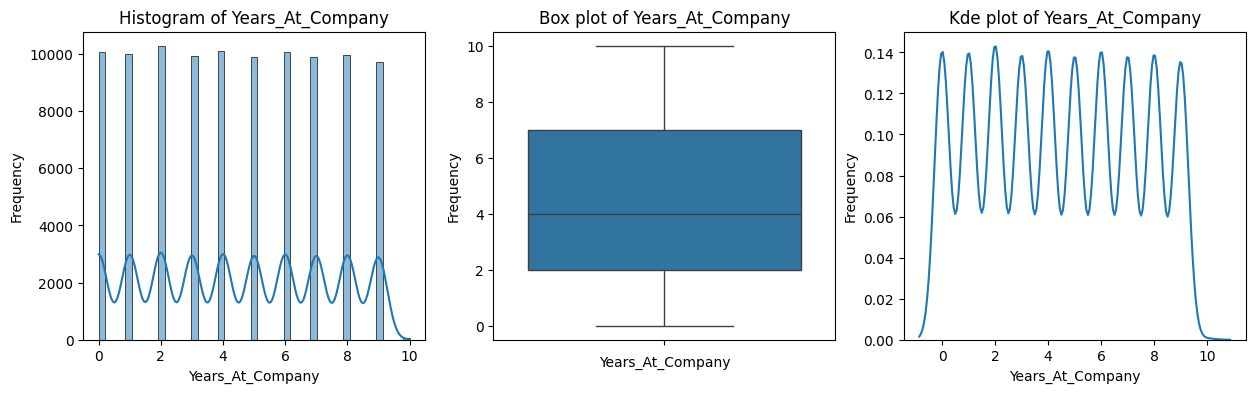


 ========== Performance_Score ==========
Mean 2.99543
Median 3.0
Min 1
Max 5
Std 1.4147258142800536
Skew 0.004008483876873582
Kurtosis -1.300642815218507
Var 2.0014491295903607
Quantiles:
0.25    2.0
0.50    3.0
0.75    4.0
Name: Performance_Score, dtype: float64
IQR
2.0
MAD: 1.2013918438


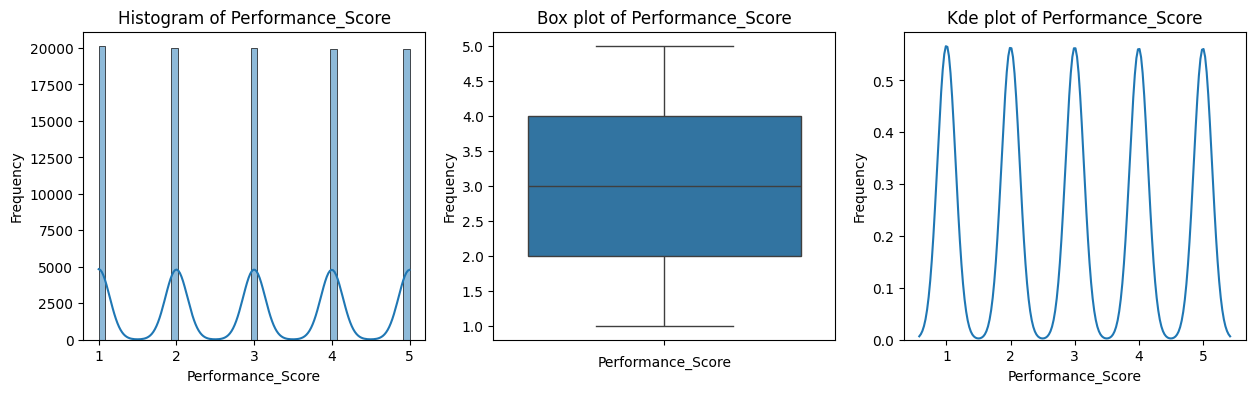


 ========== Monthly_Salary ==========
Mean 6403.211
Median 6500.0
Min 3850.0
Max 9000.0
Std 1372.5087166506169
Skew 0.1012908017990116
Kurtosis -0.8749904643306627
Var 1883780.1772819234
Quantiles:
0.25    5250.0
0.50    6500.0
0.75    7500.0
Name: Monthly_Salary, dtype: float64
IQR
2250.0
MAD: 1150.5340002399998


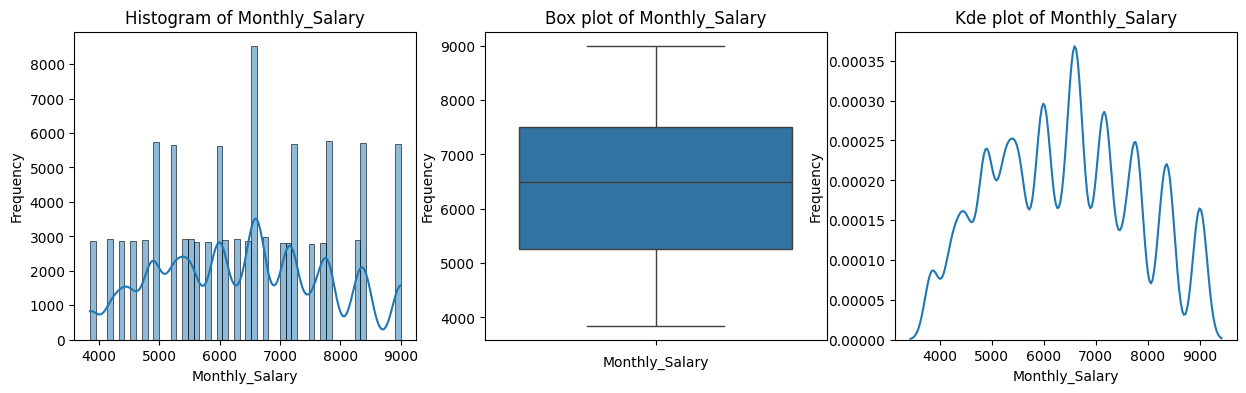


 ========== Work_Hours_Per_Week ==========
Mean 44.95695
Median 45.0
Min 30
Max 60
Std 8.942002923935492
Skew 0.009621030975014756
Kurtosis -1.2042881022727938
Var 79.9594162916709
Quantiles:
0.25    37.0
0.50    45.0
0.75    53.0
Name: Work_Hours_Per_Week, dtype: float64
IQR
16.0
MAD: 7.743011685999998


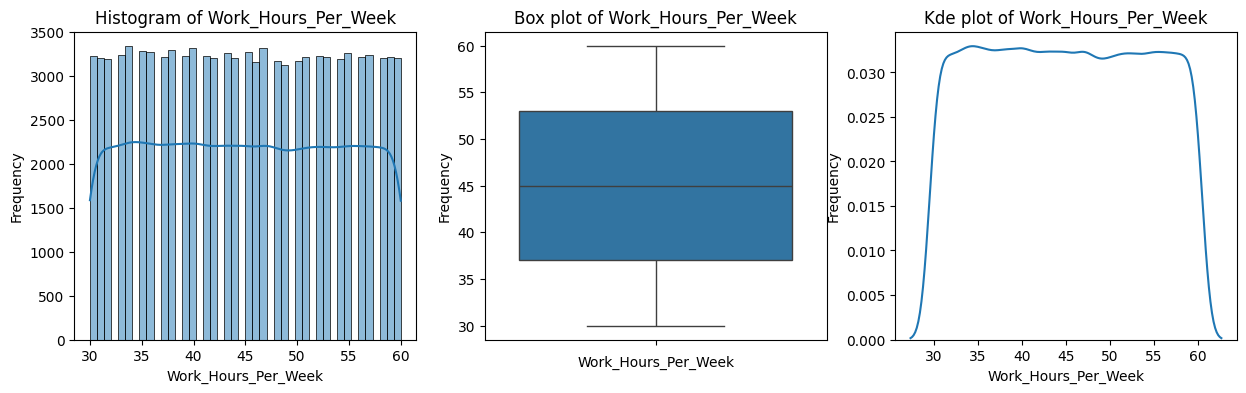


 ========== Projects_Handled ==========
Mean 24.43117
Median 24.0
Min 0
Max 49
Std 14.469583826762046
Skew 0.009682007877170098
Kurtosis -1.2082436559687835
Var 209.36885611969376
Quantiles:
0.25    12.0
0.50    24.0
0.75    37.0
Name: Projects_Handled, dtype: float64
IQR
25.0
MAD: 12.552085850000003


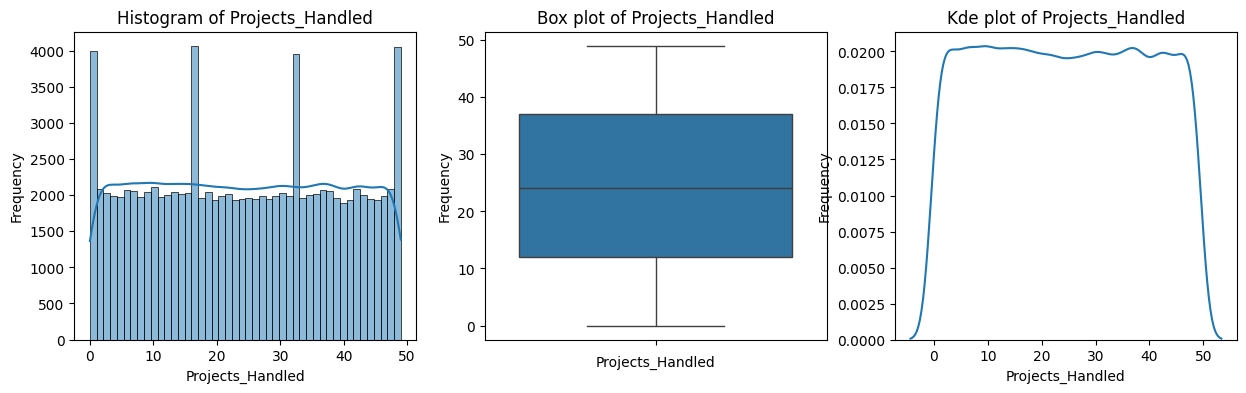


 ========== Overtime_Hours ==========
Mean 14.51493
Median 15.0
Min 0
Max 29
Std 8.664026070400833
Skew -0.0011665191710081724
Kurtosis -1.203161391594788
Var 75.0653477485853
Quantiles:
0.25     7.0
0.50    15.0
0.75    22.0
Name: Overtime_Hours, dtype: float64
IQR
15.0
MAD: 7.506310889600001


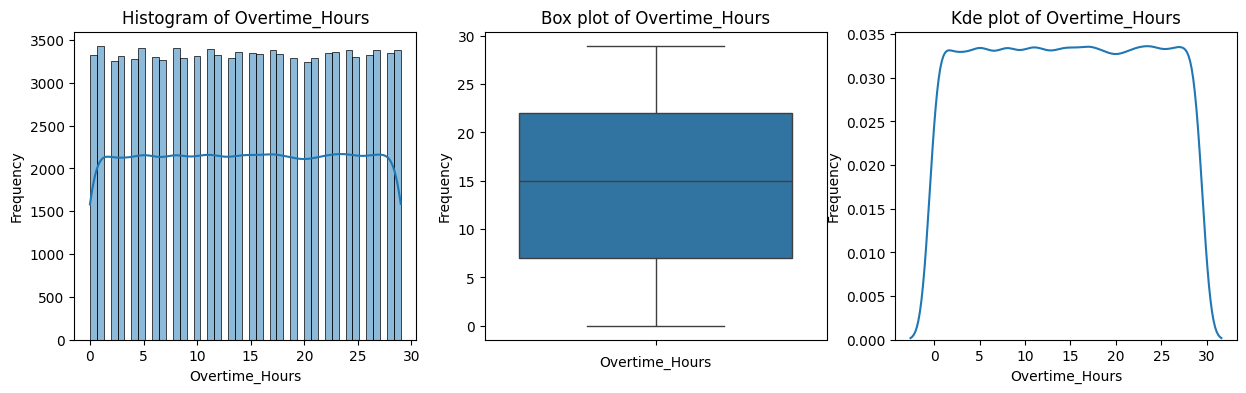


 ========== Sick_Days ==========
Mean 7.00855
Median 7.0
Min 0
Max 14
Std 4.331591453997936
Skew -0.0033204033775700546
Kurtosis -1.2161561680303445
Var 18.762684524347954
Quantiles:
0.25     3.0
0.50     7.0
0.75    11.0
Name: Sick_Days, dtype: float64
IQR
8.0
MAD: 3.745019081


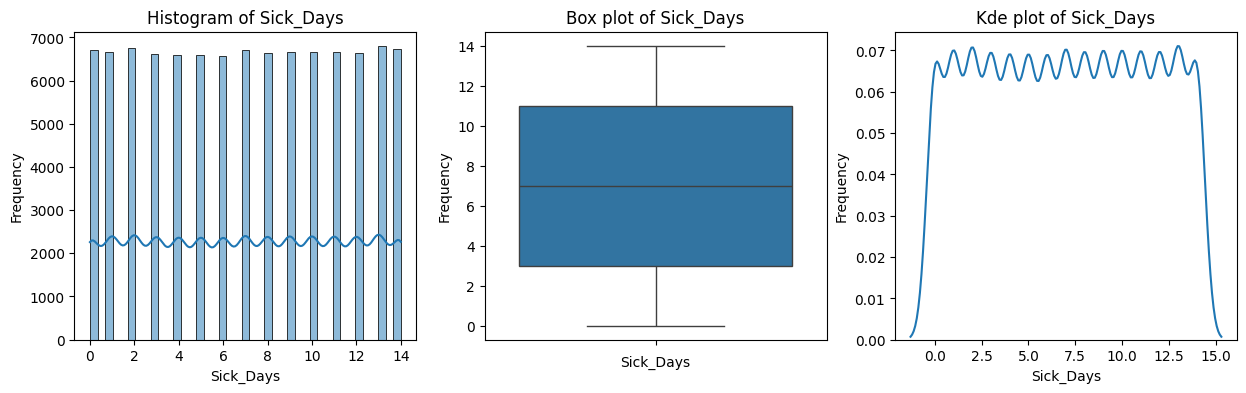


 ========== Remote_Work_Frequency ==========
Mean 50.0905
Median 50.0
Min 0
Max 100
Std 35.35115707856428
Skew -0.0019009721887309542
Kurtosis -1.3027281516846574
Var 1249.704306793325
Quantiles:
0.25    25.0
0.50    50.0
0.75    75.0
Name: Remote_Work_Frequency, dtype: float64
IQR
50.0
MAD: 30.062698179999998


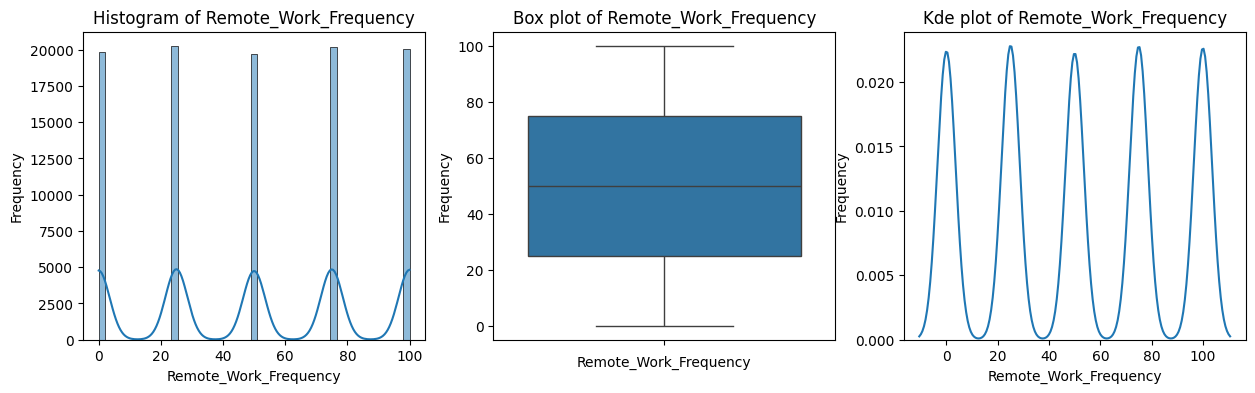


 ========== Team_Size ==========
Mean 10.01356
Median 10.0
Min 1
Max 19
Std 5.495405182621384
Skew -0.0005922444743663084
Kurtosis -1.2115415509333374
Var 30.199478121181965
Quantiles:
0.25     5.0
0.50    10.0
0.75    15.0
Name: Team_Size, dtype: float64
IQR
10.0
MAD: 4.755172304799999


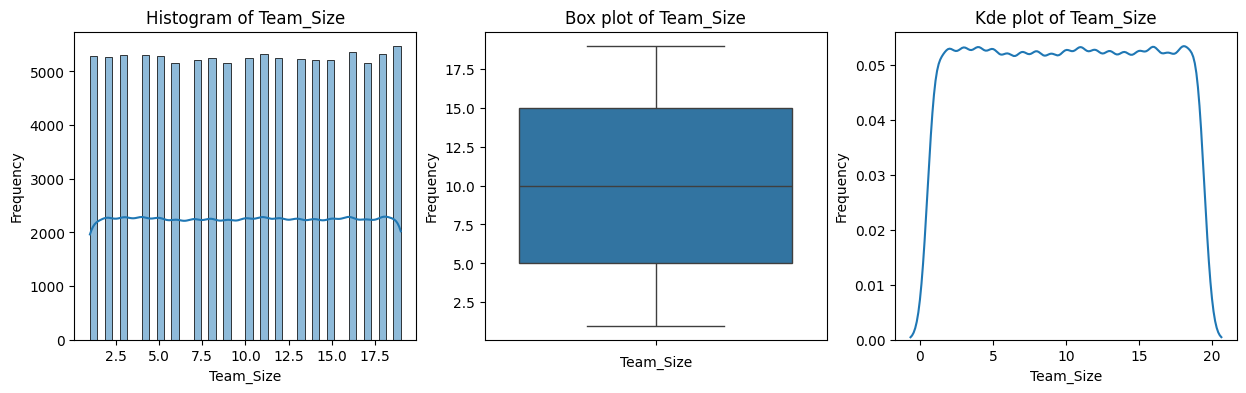


 ========== Training_Hours ==========
Mean 49.50606
Median 49.0
Min 0
Max 99
Std 28.890383344962242
Skew -0.0006484906392317161
Kurtosis -1.199558170011215
Var 834.6542498188718
Quantiles:
0.25    25.0
0.50    49.0
0.75    75.0
Name: Training_Hours, dtype: float64
IQR
50.0
MAD: 25.004466846799996


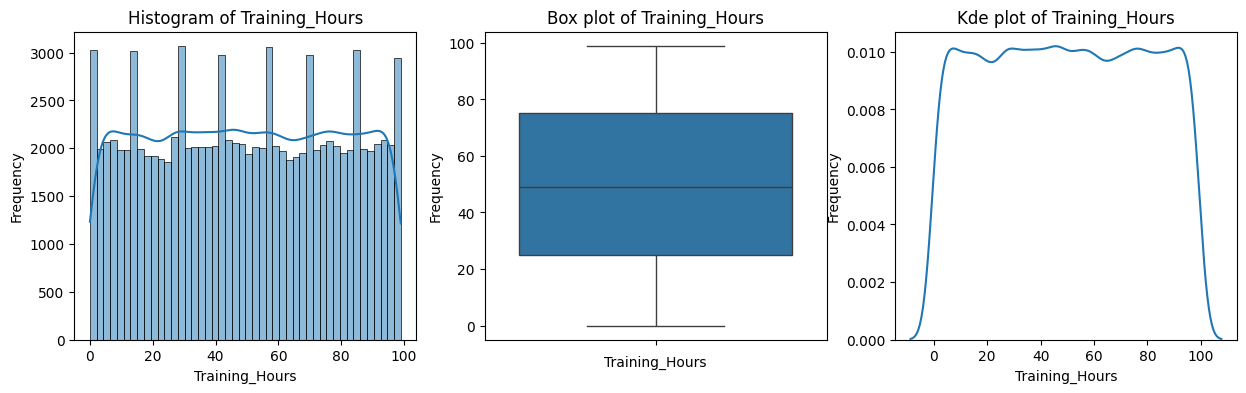


 ========== Promotions ==========
Mean 0.99972
Median 1.0
Min 0
Max 2
Std 0.8158716676445176
Skew 0.0005140031081702037
Kurtosis -1.4977009689140295
Var 0.6656465780650461
Quantiles:
0.25    0.0
0.50    1.0
0.75    2.0
Name: Promotions, dtype: float64
IQR
2.0
MAD: 0.6657335423999998


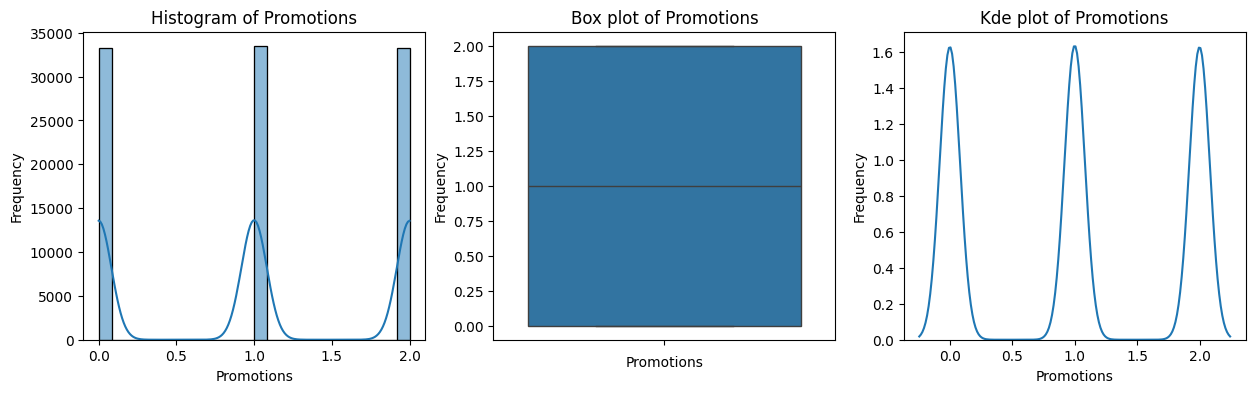


 ========== Employee_Satisfaction_Score ==========
Mean 2.9990883999999998
Median 3.0
Min 1.0
Max 5.0
Std 1.150719412601181
Skew 0.0013210585126319212
Kurtosis -1.19095441417803
Var 1.3241551665372073
Quantiles:
0.25    2.01
0.50    3.00
0.75    3.99
Name: Employee_Satisfaction_Score, dtype: float64
IQR
1.9800000000000004
MAD: 0.995505511048


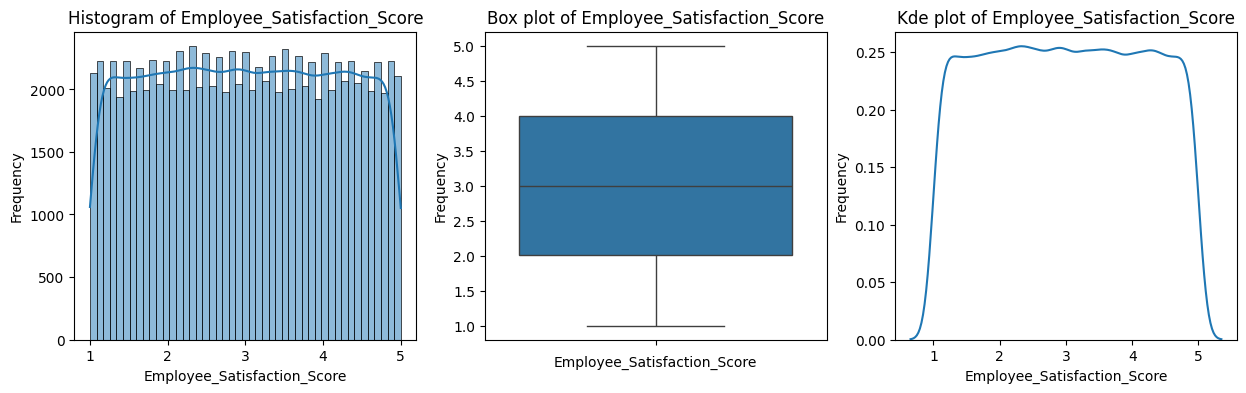


 ========== Resigned ==========
Mean 0.1001
Median 0.0
Min 0
Max 1
Std 0.30013478773513486
Skew 2.664856021373098
Kurtosis 5.101559645441382
Var 0.09008089080881444
Quantiles:
0.25    0.0
0.50    0.0
0.75    0.0
Name: Resigned, dtype: float64
IQR
0.0
MAD: 0.18015998


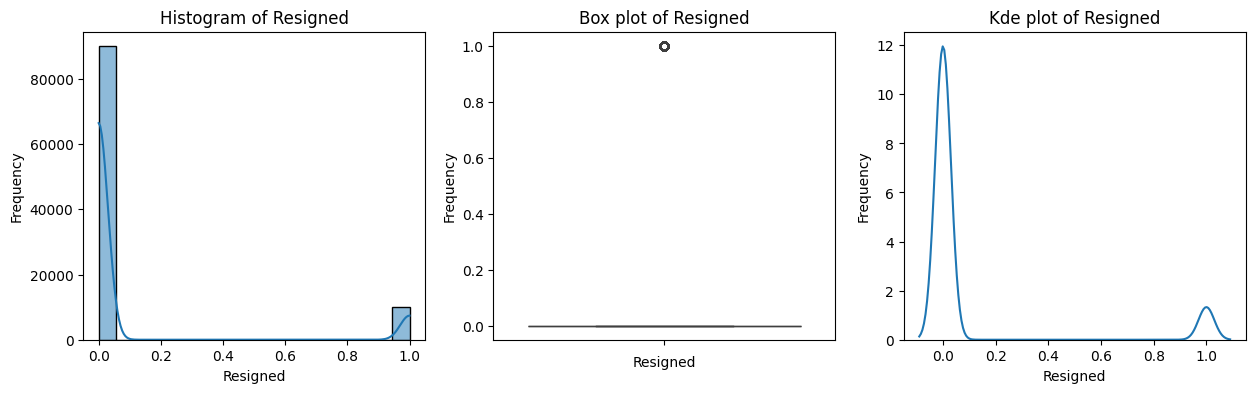


 ========== Hire_Year ==========
Mean 2019.20397
Median 2019.0
Min 2014
Max 2024
Std 2.9050491617541048
Skew -0.012005397549817326
Kurtosis -1.160337002546731
Var 8.439310632208226
Quantiles:
0.25    2017.0
0.50    2019.0
0.75    2022.0
Name: Hire_Year, dtype: float64
IQR
5.0
MAD: 2.5086804788000014


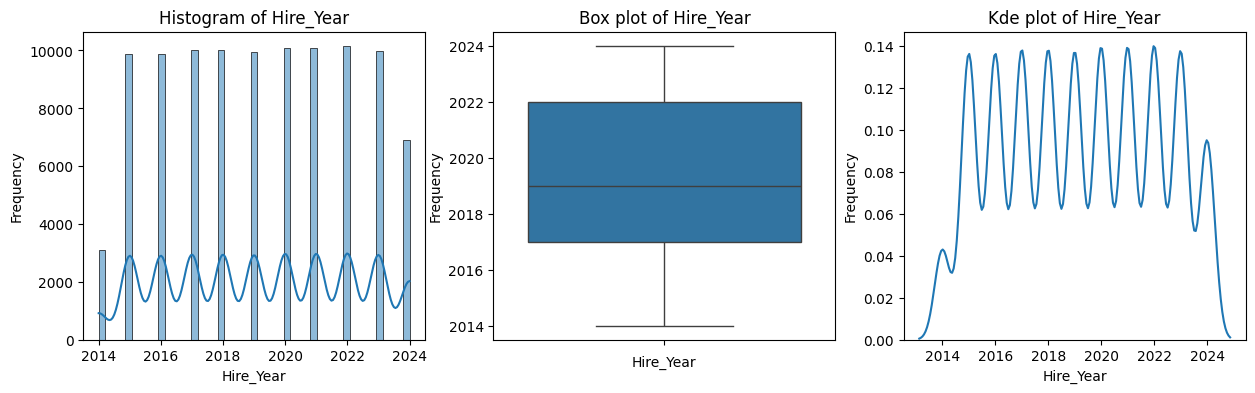

In [14]:
for col in num_cols:
  print(f"\n {'='* 10} {col} {'=' * 10}")

#----Numerical-Describe----------
  print('Mean', df[col].mean())
  print('Median', df[col].median())
  print('Min', df[col].min())
  print('Max', df[col].max())
  print('Std', df[col].std())
  print('Skew', df[col].skew())
  print('Kurtosis', df[col].kurtosis())
  print('Var', df[col].var())

  print('Quantiles:')
  print(df[col].quantile([0.25, 0.5, 0.75]))

  print("IQR")
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  print(iqr)

  #MAD
  MAD = np.mean(np.abs(df[col] - np.mean(df[col])))
  print('MAD:', MAD)

  #--------Visual------------
  plt.figure(figsize=(15, 4))

  plt.subplot(1,3,1)
  sns.histplot(df[col], kde=True)
  plt.title(f"Histogram of {col}")
  plt.xlabel(col)
  plt.ylabel('Frequency')

  plt.subplot(1,3,2)
  sns.boxplot(df[col])
  plt.title(f"Box plot of {col}")
  plt.xlabel(col)
  plt.ylabel('Frequency')

  plt.subplot(1,3,3)
  sns.kdeplot(df[col])
  plt.title(f"Kde plot of {col}")
  plt.xlabel(col)
  plt.ylabel('Frequency')

  plt.show()

## **Insights**:-
**Age**:

Average age is around 41 years

Employees are evenly distributed across age groups

Most employees fall between 31 to 51 years

**Years_At_Company**:

Average experience is around 4–5 years

Most employees have 2 to 7 years of tenure

Experience is evenly distributed across employees

**Performance_Score**:

Average performance score is around 3

Most employees are rated between 2 to 4

Performance is evenly distributed

**Monthly_Salary**:

Average salary is around 6400–6500

Most employees earn between 5250 to 7500

Salary distribution is fairly balanced

**Work_Hours_Per_Week**:

Average work time is around 45 hours/week

Most employees work between 37 to 53 hours

Work hours are evenly distributed

**Projects_Handled**:

Employees handle around 24 projects on average

Most handle between 12 to 37 projects

Workload is evenly distributed

**Overtime_Hours**:

Average overtime is around 14–15 hours

Most employees do 7 to 22 hours overtime

Overtime is evenly spread

**Sick_Days**:

Employees take around 7 sick days on average

Most take between 3 to 11 days

Sick leave usage is consistent

**Remote_Work_Frequency**:

Average remote work is around 50%

Most employees range between 25% to 75%

Remote work varies widely across employees

**Team_Size**:

Average team size is around 10 members

Most teams have 5 to 15 members

Team size is evenly distributed

**Training_Hours**:

Employees receive around 49–50 training hours

Most get between 25 to 75 hours

Training is evenly distributed

**Promotions**:

Employees have around 1 promotion on average

Most have between 0 to 2 promotions

Career growth is steady

**Employee_Satisfaction_Score**:

Average satisfaction score is around 3

Most employees rate between 2 to 4

Satisfaction levels are balanced

**Resigned**:

Around 10% employees have resigned

Majority of employees have not resigned

Shows high employee retention

**Hire_Year**:

Average hiring year is around 2019

Most employees were hired between 2017 to 2022

Workforce is relatively recent

**Hire_Month**:

Hiring is spread across all months

No strong seasonal pattern observed

Distribution is fairly balanced

### **Categorical (Non-Visual & Visual)**


========== Department ==========
Count: 100000
Unique values: ['IT' 'Finance' 'Customer Support' 'Engineering' 'Marketing' 'HR'
 'Operations' 'Sales' 'Legal']
No. of unique values: 9
Mode: Marketing
Value Counts:
Department
Marketing           11216
Finance             11200
Operations          11181
IT                  11131
Sales               11122
Legal               11118
Customer Support    11116
HR                  10960
Engineering         10956
Name: count, dtype: int64
Percentage Distribution:
Department
Marketing           11.22
Finance             11.20
Operations          11.18
IT                  11.13
Sales               11.12
Legal               11.12
Customer Support    11.12
HR                  10.96
Engineering         10.96
Name: proportion, dtype: float64


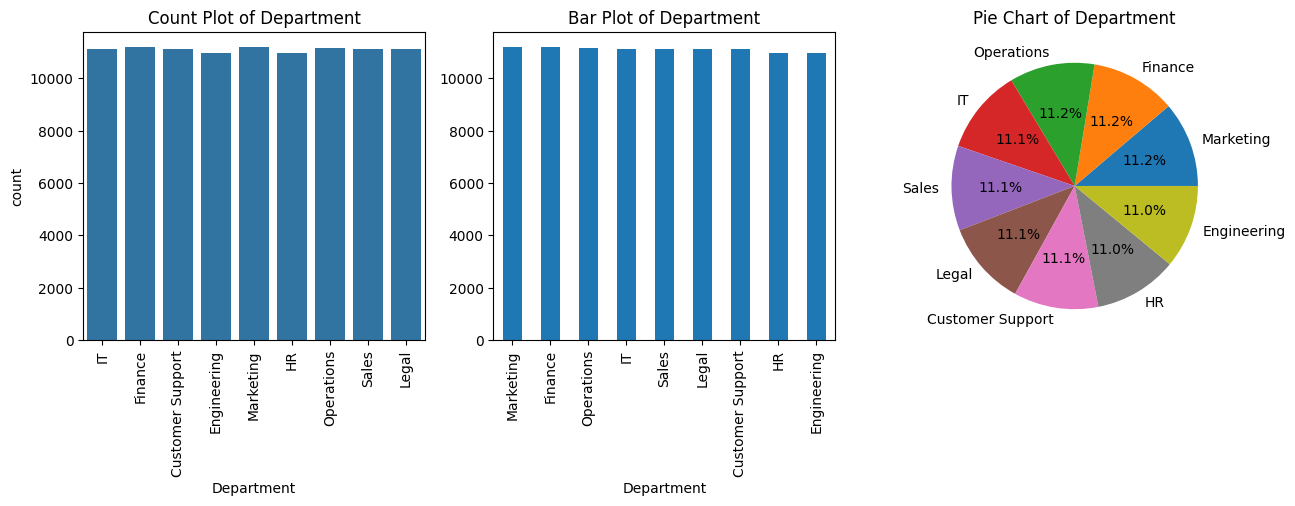


========== Gender ==========
Count: 100000
Unique values: ['Male' 'Female' 'Other']
No. of unique values: 3
Mode: Male
Value Counts:
Gender
Male      48031
Female    48001
Other      3968
Name: count, dtype: int64
Percentage Distribution:
Gender
Male      48.03
Female    48.00
Other      3.97
Name: proportion, dtype: float64


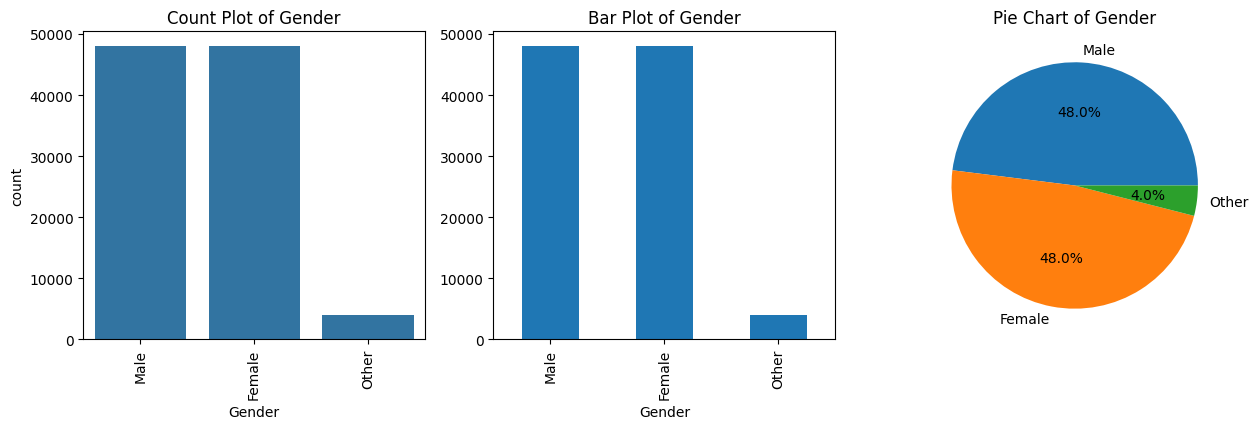


========== Job_Title ==========
Count: 100000
Unique values: ['Specialist' 'Developer' 'Analyst' 'Manager' 'Technician' 'Engineer'
 'Consultant']
No. of unique values: 7
Mode: Specialist
Value Counts:
Job_Title
Specialist    14507
Manager       14325
Technician    14285
Analyst       14261
Engineer      14217
Consultant    14210
Developer     14195
Name: count, dtype: int64
Percentage Distribution:
Job_Title
Specialist    14.51
Manager       14.32
Technician    14.28
Analyst       14.26
Engineer      14.22
Consultant    14.21
Developer     14.19
Name: proportion, dtype: float64


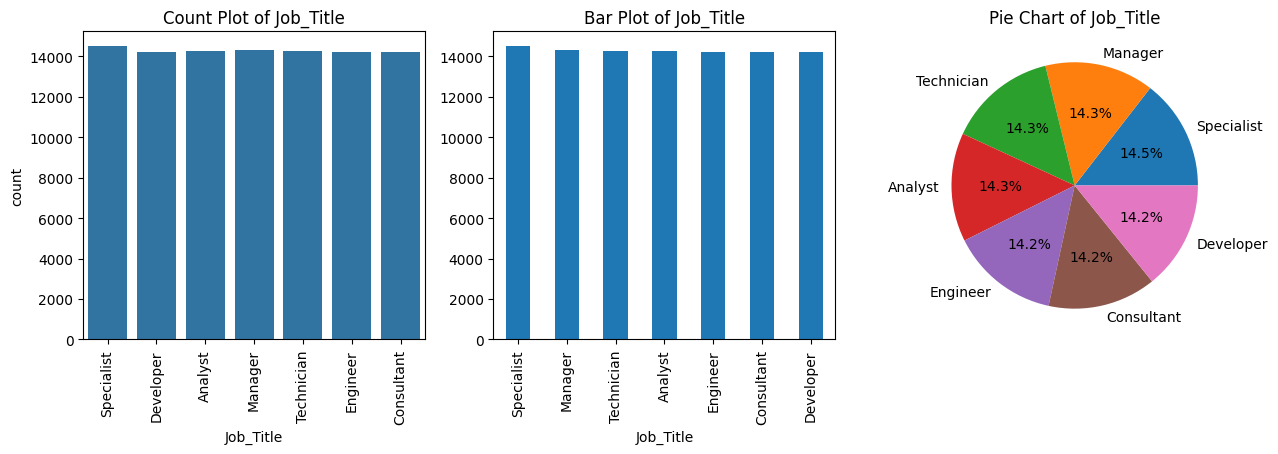


========== Education_Level ==========
Count: 100000
Unique values: ['High School' 'Bachelor' 'Master' 'PhD']
No. of unique values: 4
Mode: Bachelor
Value Counts:
Education_Level
Bachelor       50041
High School    30004
Master         14904
PhD             5051
Name: count, dtype: int64
Percentage Distribution:
Education_Level
Bachelor       50.04
High School    30.00
Master         14.90
PhD             5.05
Name: proportion, dtype: float64


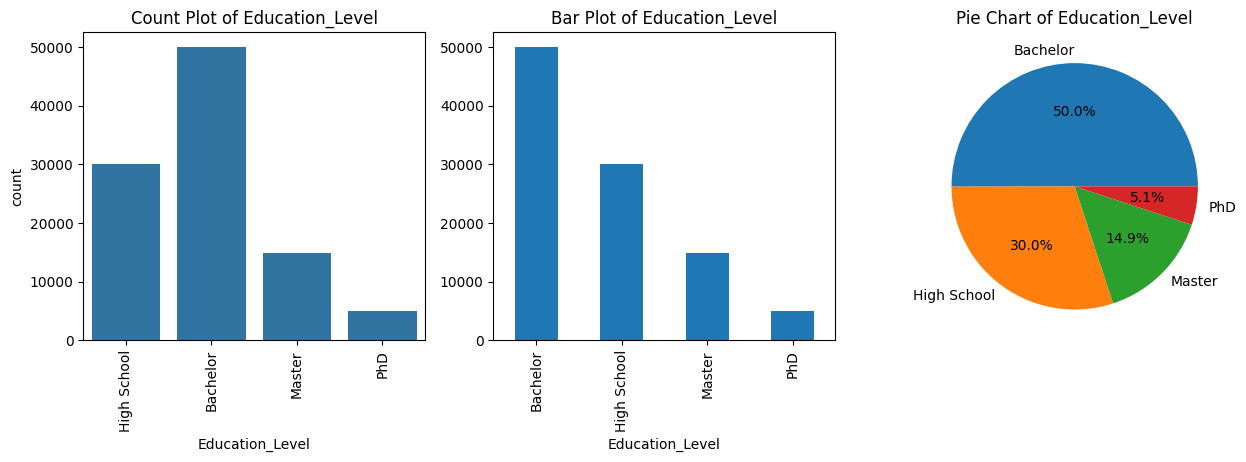


========== Hire_Month ==========
Count: 100000
Unique values: ['Jan' 'Apr' 'Oct' 'Jul' 'Aug' 'Jun' 'Dec' 'Nov' 'Feb' 'Mar' 'Sep' 'May']
No. of unique values: 12
Mode: Oct
Value Counts:
Hire_Month
Oct    8662
May    8490
Jul    8477
Aug    8445
Dec    8442
Jan    8406
Mar    8402
Sep    8300
Jun    8254
Apr    8167
Nov    8140
Feb    7815
Name: count, dtype: int64
Percentage Distribution:
Hire_Month
Oct    8.66
May    8.49
Jul    8.48
Aug    8.44
Dec    8.44
Jan    8.41
Mar    8.40
Sep    8.30
Jun    8.25
Apr    8.17
Nov    8.14
Feb    7.82
Name: proportion, dtype: float64


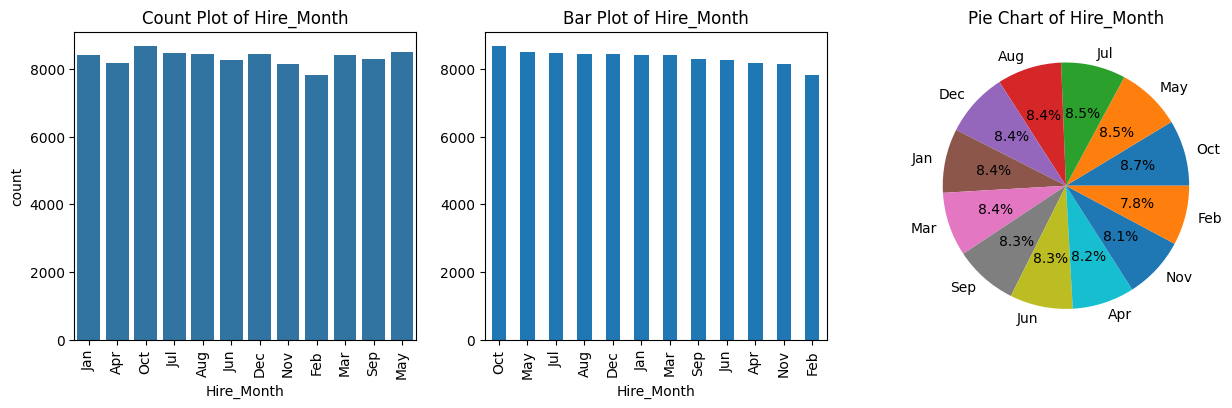

In [15]:
for col in cat_cols:
    print(f"\n{'='*10} {col} {'='*10}")

    # -------- Categorical-Describe ----------
    print("Count:", df[col].count())
    print("Unique values:", df[col].unique())
    print("No. of unique values:", df[col].nunique())
    print("Mode:", df[col].mode()[0])

    print("Value Counts:")
    print(df[col].value_counts())

    print("Percentage Distribution:")
    print(round(df[col].value_counts(normalize=True) * 100, 2))

    # ---------Categorical- Visual ----------
    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    sns.countplot(x=df[col])
    plt.xticks(rotation=90)
    plt.title(f"Count Plot of {col}")

    plt.subplot(1,3,2)
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Bar Plot of {col}")

    plt.subplot(1,3,3)
    df[col].value_counts().plot(kind="pie", autopct="%1.1f%%")
    plt.title(f"Pie Chart of {col}")
    plt.ylabel("")

    plt.show()

## **Insights**:-

**Department**:

Employees are evenly spread across all departments

No single department dominates the workforce

Marketing has the highest share but only slightly

**Gender**:

Male and Female employees are almost equal

Workforce shows strong gender balance

A small portion (~4%) belongs to other categories

**Job_Title**:

All job roles have almost equal distribution

No role is highly concentrated

Specialist role has a slightly higher count

**Education_Level**:

Most employees have a Bachelor’s degree

High School is the second most common

Very few employees have a PhD

**Hire_Month**:

Hiring happens throughout the year

October has the highest hiring

February has the lowest hiring

# **Inferential Statistics**
# **Bi-variate Analysis**
### **Numerical vs Target Variable** (Target = Resigned)

In [16]:
from scipy import stats
import random
from scipy.stats import ttest_ind


---------------------------
Column: Age


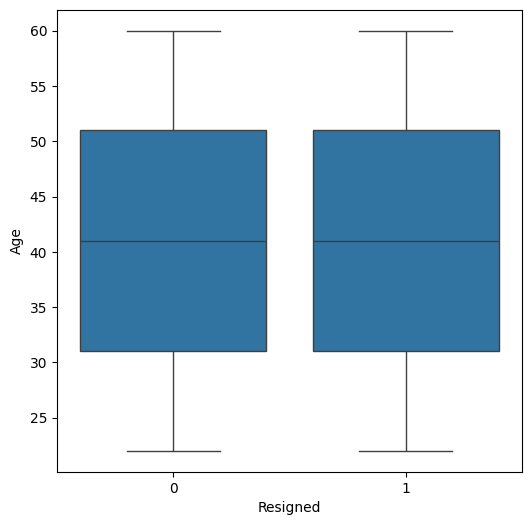

t-test: 1.7078080808829936
p-value: 0.08924130788698559
---------------------------
There is no statistically significant difference in 'Age' between the Resigned.

---------------------------
Column: Years_At_Company


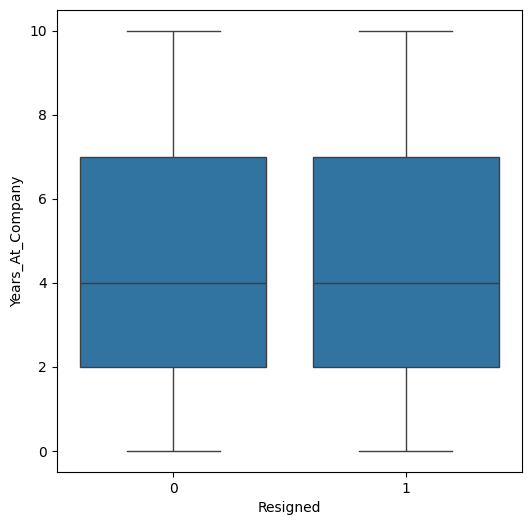

t-test: 0.497506156362694
p-value: 0.6193945578458211
---------------------------
There is no statistically significant difference in 'Years_At_Company' between the Resigned.

---------------------------
Column: Performance_Score


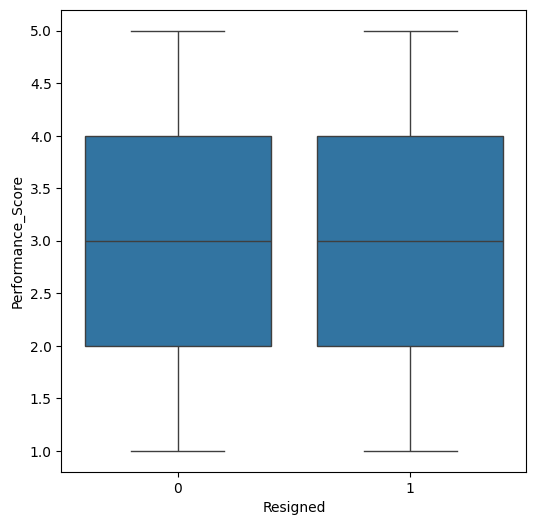

t-test: 0.8975103686746211
p-value: 0.37053666768803617
---------------------------
There is no statistically significant difference in 'Performance_Score' between the Resigned.

---------------------------
Column: Monthly_Salary


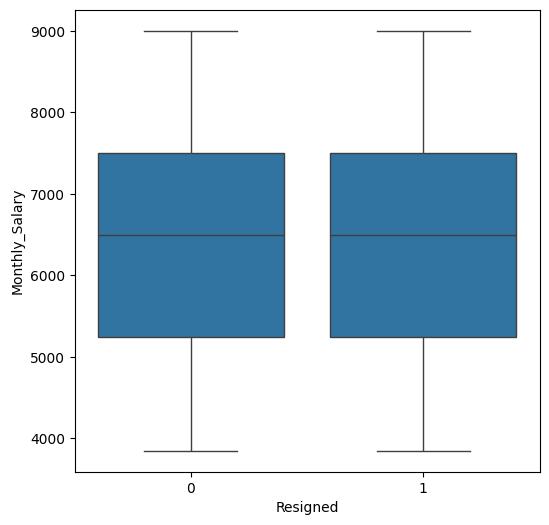

t-test: -0.25715350579920015
p-value: 0.7973276679612087
---------------------------
There is no statistically significant difference in 'Monthly_Salary' between the Resigned.

---------------------------
Column: Work_Hours_Per_Week


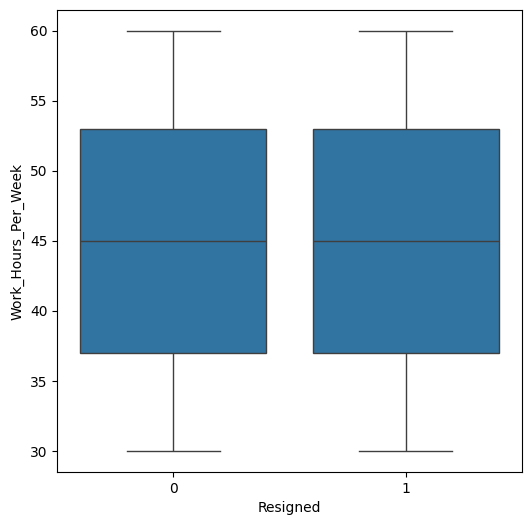

t-test: -0.8445556947466457
p-value: 0.39938965451699904
---------------------------
There is no statistically significant difference in 'Work_Hours_Per_Week' between the Resigned.

---------------------------
Column: Projects_Handled


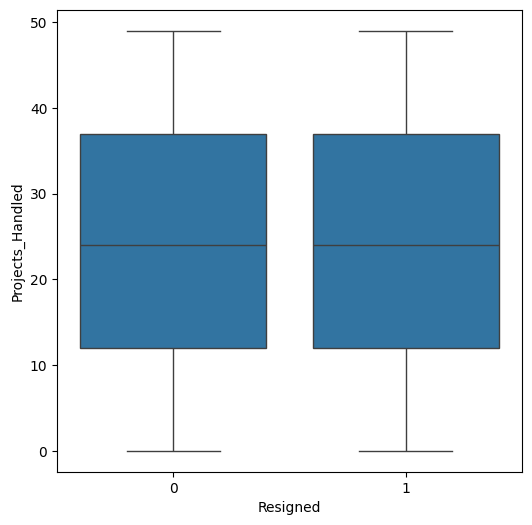

t-test: 0.08918226271026519
p-value: 0.9290277822683225
---------------------------
There is no statistically significant difference in 'Projects_Handled' between the Resigned.

---------------------------
Column: Overtime_Hours


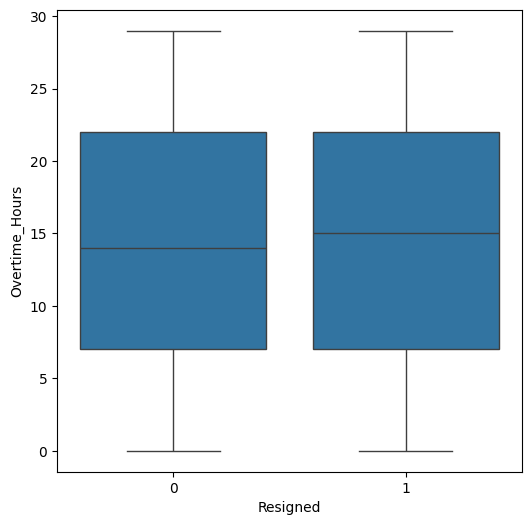

t-test: -0.9470127301445617
p-value: 0.3448019286245988
---------------------------
There is no statistically significant difference in 'Overtime_Hours' between the Resigned.

---------------------------
Column: Sick_Days


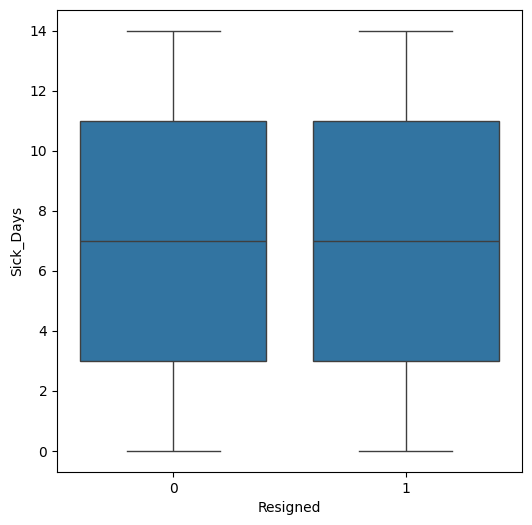

t-test: 0.7592750166212734
p-value: 0.44859346759103513
---------------------------
There is no statistically significant difference in 'Sick_Days' between the Resigned.

---------------------------
Column: Remote_Work_Frequency


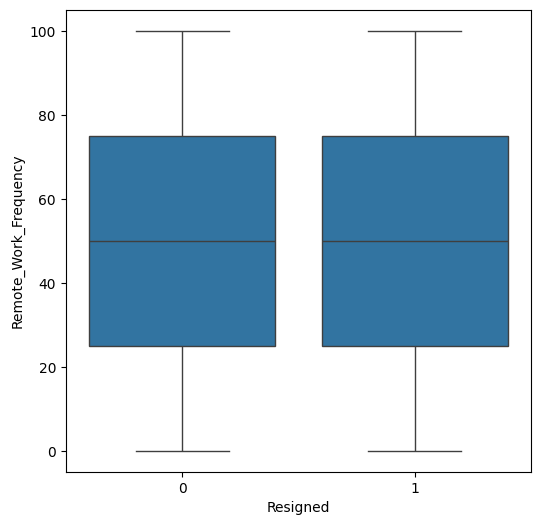

t-test: -0.5028781980440686
p-value: 0.6156093176970883
---------------------------
There is no statistically significant difference in 'Remote_Work_Frequency' between the Resigned.

---------------------------
Column: Team_Size


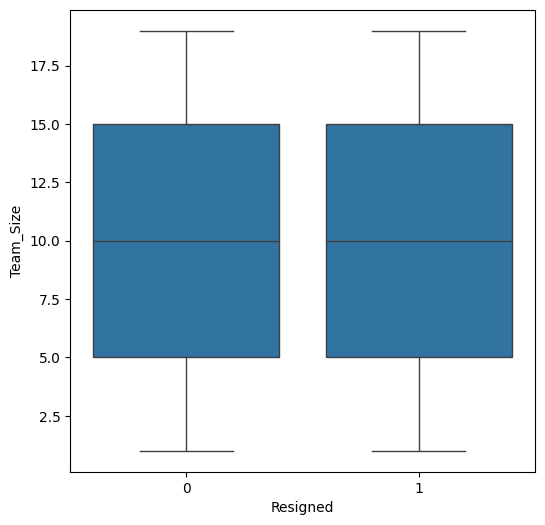

t-test: 0.2698534602948444
p-value: 0.7875542504907049
---------------------------
There is no statistically significant difference in 'Team_Size' between the Resigned.

---------------------------
Column: Training_Hours


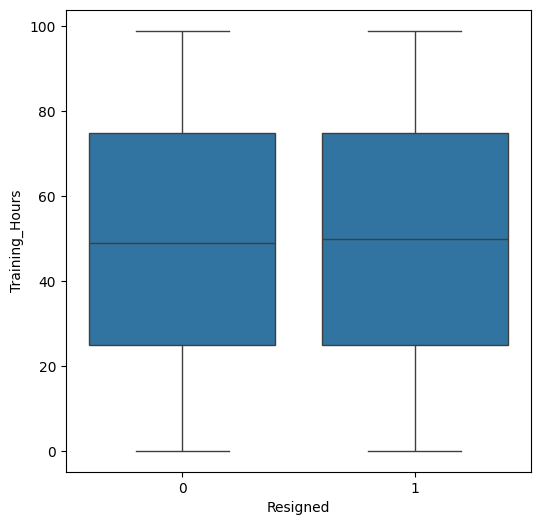

t-test: 1.4702778244883556
p-value: 0.1430944240790478
---------------------------
There is no statistically significant difference in 'Training_Hours' between the Resigned.

---------------------------
Column: Promotions


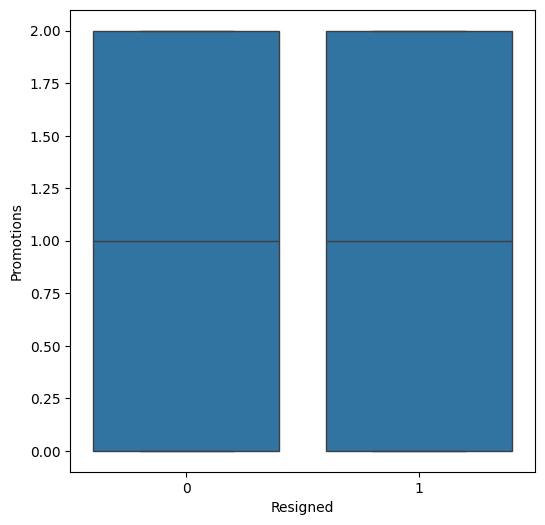

t-test: -0.2614468021983563
p-value: 0.7940201795469384
---------------------------
There is no statistically significant difference in 'Promotions' between the Resigned.

---------------------------
Column: Employee_Satisfaction_Score


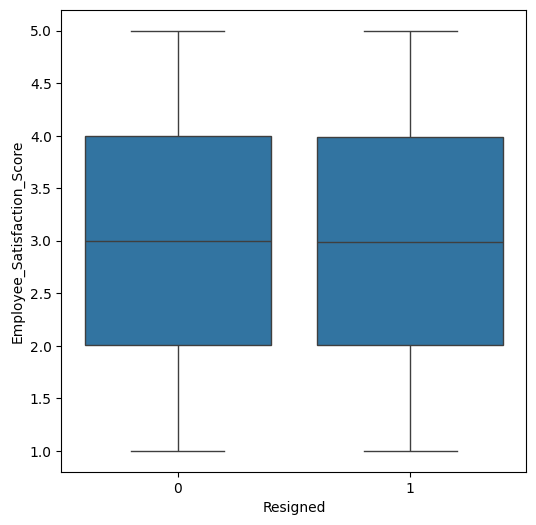

t-test: 1.8510339918301901
p-value: 0.06565538269111033
---------------------------
There is no statistically significant difference in 'Employee_Satisfaction_Score' between the Resigned.

---------------------------
Column: Hire_Year


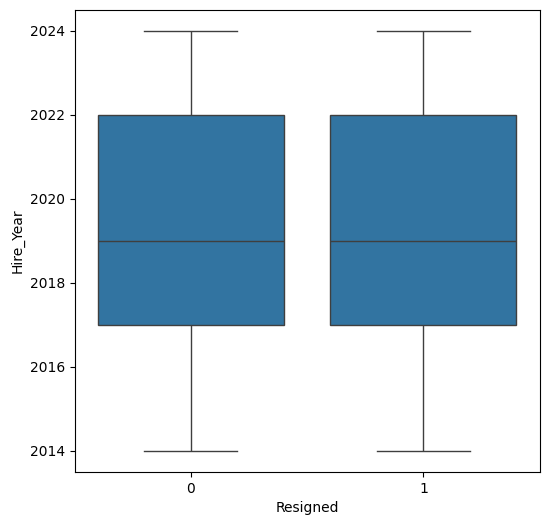

t-test: -0.44912189511226724
p-value: 0.6538362537833696
---------------------------
There is no statistically significant difference in 'Hire_Year' between the Resigned.


In [17]:
# target variable
target = "Resigned"

# numerical columns and drop target variable
stat_cols = df.select_dtypes(include=np.number).columns.drop(target)

for col in stat_cols:

    print("\n---------------------------")
    print("Column:", col)

    # outlier remove
    temp = df[(np.abs(stats.zscore(df[col])) < 3)]

    # boxplot
    plt.figure(figsize=(6,6))
    sns.boxplot(x=target, y=col, data=df)
    plt.show()

    # group split
    Resigned1 = df[df[target] == 1][col].values.tolist()
    Resigned0 = df[df[target] == 0][col].values.tolist()

    # sampling
    size = min(len(Resigned1), len(Resigned0), 100)

    Resigned1 = random.sample(Resigned1, size)
    Resigned0 = random.sample(Resigned0, size)

    # t-test
    ttest, pval = ttest_ind(Resigned1, Resigned0, equal_var=False)

    print("t-test:", ttest)
    print("p-value:", pval)
    print("---------------------------")
    if pval < 0.05:
      print(f"There is a statistically significant difference in '{col}' between the Resigned.")
    else:
      print(f"There is no statistically significant difference in '{col}' between the Resigned.")

**Overall Insight (T-test Results)**:

No variable shows a statistically significant difference (all p-values > 0.05)

Resigned and non-resigned employees are very similar across all factors

No strong predictor of resignation found from these numerical columns
**********************
**Age**:

No significant difference between resigned and non-resigned

Age does not impact resignation

Both groups have similar age distribution

**Years_At_Company**:

No significant difference observed

Experience level does not affect resignation

Similar tenure across both groups

**Performance_Score**:

Performance is similar for both groups

No impact of performance on resignation

High and low performers behave similarly

**Monthly_Salary**:

Salary does not significantly differ

Pay level is not a key factor in resignation

Both groups earn similar salaries

**Work_Hours_Per_Week**:

Work hours are similar across groups

No strong link with resignation

Slight difference but not significant

**Projects_Handled**:

Workload is similar for both groups

Number of projects does not affect resignation

No significant impact observed

**Overtime_Hours**:

Overtime is similar across groups

Extra work hours do not influence resignation

No meaningful difference

**Sick_Days**:

Sick leave usage is similar

No relation with resignation

Both groups show similar patterns

**Remote_Work_Frequency**:

Remote work usage is similar

No impact on resignation

Flexible work does not drive exit

**Team_Size**:

Team size does not differ significantly

No effect on resignation

Employees work in similar team sizes

**Training_Hours**:

Training exposure is similar

No impact on resignation

Learning opportunities are equal

**Promotions**:

Promotion count is similar

Career growth does not impact resignation

No significant difference

**Employee_Satisfaction_Score**:

Satisfaction levels are similar

Does not strongly affect resignation

Both groups show similar satisfaction

**Hire_Year**:

Hiring year is similar across groups

No trend with resignation

Workforce timing does not impact exits

# **Bi-variate Analysis**
### **Categorical vs Target**

In [18]:
from scipy.stats import chi2_contingency


Feature: Department


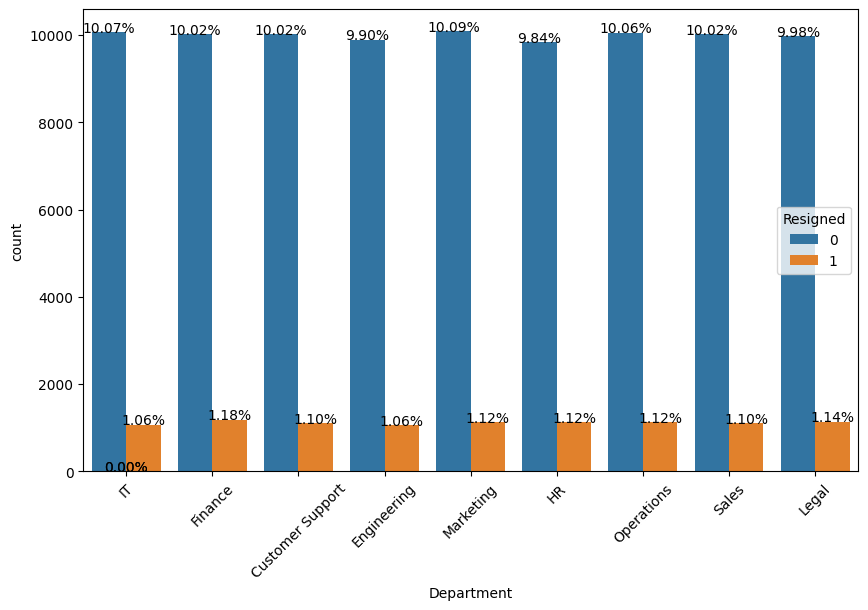

Chi-square statistic: 9.179
p-value: 0.32738
Degrees of freedom: 8
Result: No statistically significant association found between 'Department' and Resigned.
Insight: 'Department' does not appear to strongly influence Resigned.

Feature: Gender


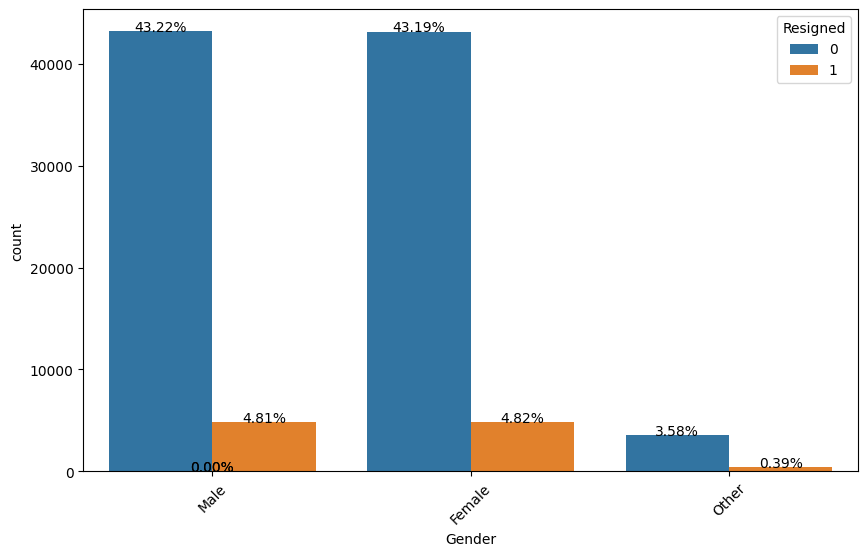

Chi-square statistic: 0.32
p-value: 0.85233
Degrees of freedom: 2
Result: No statistically significant association found between 'Gender' and Resigned.
Insight: 'Gender' does not appear to strongly influence Resigned.

Feature: Job_Title


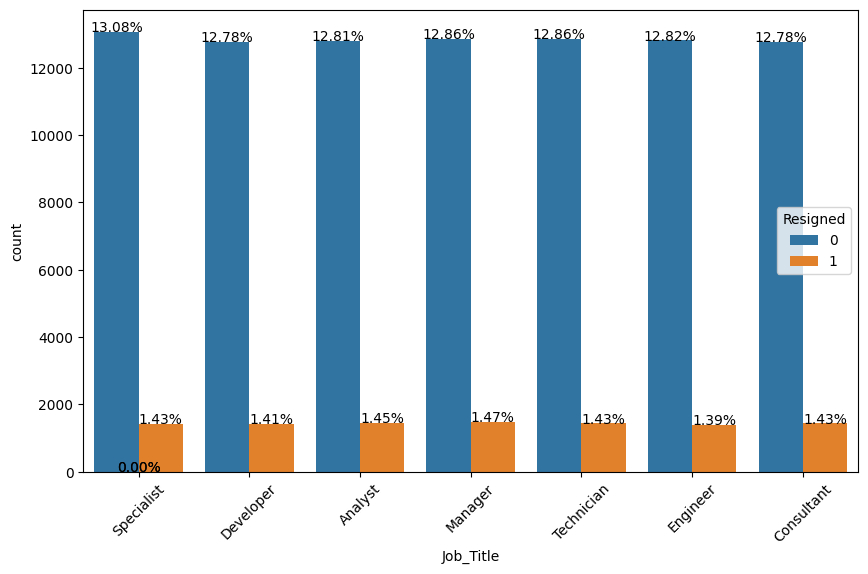

Chi-square statistic: 2.716
p-value: 0.84352
Degrees of freedom: 6
Result: No statistically significant association found between 'Job_Title' and Resigned.
Insight: 'Job_Title' does not appear to strongly influence Resigned.

Feature: Education_Level


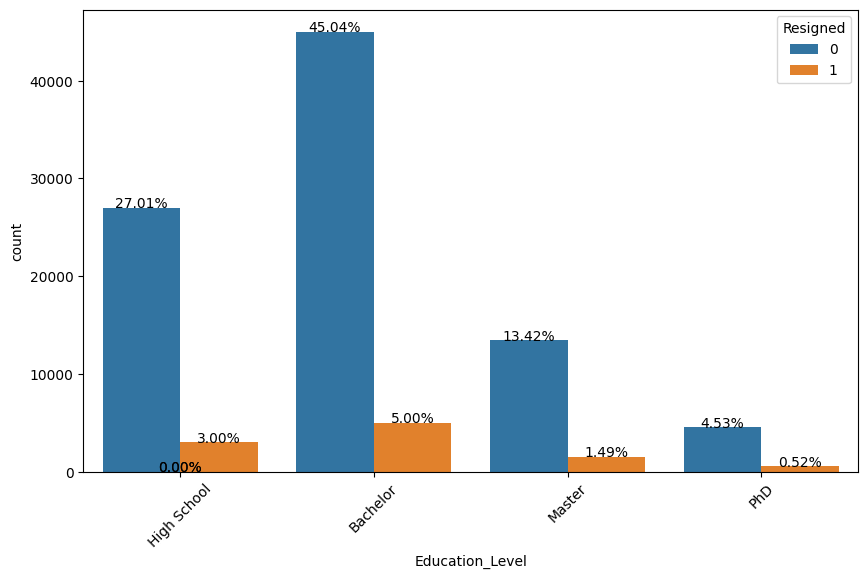

Chi-square statistic: 0.554
p-value: 0.90685
Degrees of freedom: 3
Result: No statistically significant association found between 'Education_Level' and Resigned.
Insight: 'Education_Level' does not appear to strongly influence Resigned.

Feature: Hire_Month


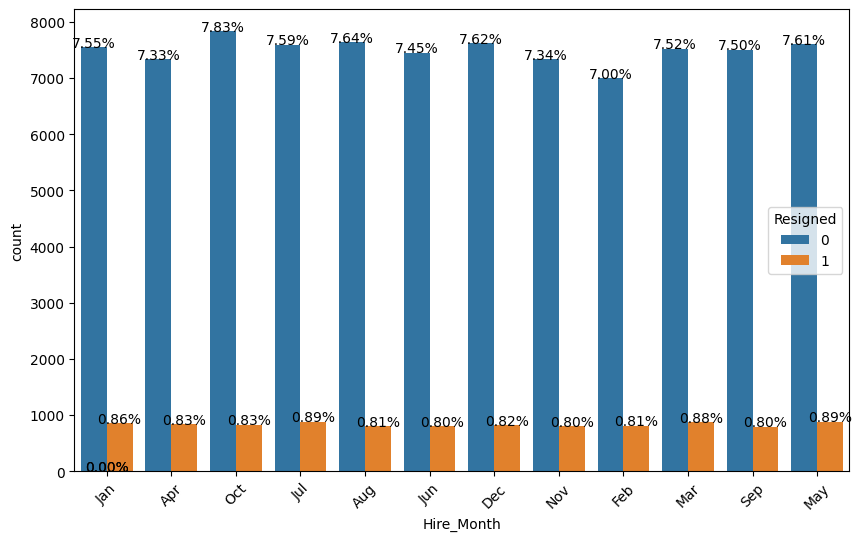

Chi-square statistic: 14.687
p-value: 0.19726
Degrees of freedom: 11
Result: No statistically significant association found between 'Hire_Month' and Resigned.
Insight: 'Hire_Month' does not appear to strongly influence Resigned.


In [19]:
target = "Resigned"

for col in cat_cols:

    print("\n================================")
    print("Feature:", col)

    # Countplot
    plt.figure(figsize=(10,6))
    total = float(len(df[target]))

    ax = sns.countplot(x=col, hue=target, data=df)

    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x()+p.get_width()/2.,
                height + 3,
                '{:1.2f}%'.format((height/total)*100),
                ha="center")

    plt.xticks(rotation=45)
    plt.show()

    # Contingency table
    c_t = pd.crosstab(df[col], df[target])

    # Chi-square test
    stat, p, dof, expected = chi2_contingency(c_t)

    print("Chi-square statistic:", round(stat,3))
    print("p-value:", round(p,5))
    print("Degrees of freedom:", dof)

    if p < 0.05:
        print(f"Result: There is a statistically significant association between '{col}' and Resigned.")
        print(f"Insight: '{col}' may influence Resigned.")
    else:
        print(f"Result: No statistically significant association found between '{col}' and Resigned.")
        print(f"Insight: '{col}' does not appear to strongly influence Resigned.")

**Overall Insight (Chi-square Results)**:

No categorical variable shows significant association (all p-values > 0.05)

Resignation is independent of these categorical factors

No strong pattern found in employee exit behavior

**Department**:

No significant link with resignation

Employees leave equally across departments

Department does not influence exit

**Gender**:

No association with resignation

Male and Female show similar behavior

Gender does not impact exit

**Job_Title**:

No significant relationship found

All roles have similar resignation patterns

Job role does not influence exit

**Education_Level**:

No impact on resignation

All education levels behave similarly

Qualification does not affect exit

**Hire_Month**:

No seasonal pattern in resignation

Employees leave equally across months

Hiring time does not influence exit

# **Model Building**

In [20]:
df = df.drop(['Hire_Year', 'Hire_Month'], axis=1)
ml_data = df.copy()
ml_data.to_csv('ml_data.csv', index=False)

In [22]:
df.head()

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,IT,Male,55,Specialist,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,0
1,Finance,Male,29,Developer,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,0
2,Finance,Male,55,Specialist,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,0
3,Customer Support,Female,48,Analyst,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,0
4,Engineering,Female,36,Analyst,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,0


## **Encoding Categorical Features**

In [23]:
cat_list = []
for col in df.columns:
    if df[col].dtype == 'object':
        cat_ftr = col
        cat_val = df[col].unique()
        cat_list.append([cat_ftr, cat_val])
print(cat_list)

[['Department', array(['IT', 'Finance', 'Customer Support', 'Engineering', 'Marketing',
       'HR', 'Operations', 'Sales', 'Legal'], dtype=object)], ['Gender', array(['Male', 'Female', 'Other'], dtype=object)], ['Job_Title', array(['Specialist', 'Developer', 'Analyst', 'Manager', 'Technician',
       'Engineer', 'Consultant'], dtype=object)], ['Education_Level', array(['High School', 'Bachelor', 'Master', 'PhD'], dtype=object)]]


In [24]:
# Categorical Encoding Mapping
dept_dict = {'IT':0, 'Finance':1, 'Customer Support':2, 'Engineering':3, 'Marketing':4, 'HR':5, 'Operations':6, 'Sales':7, 'Legal':8}
gender_dict = {'Male':0, 'Female':1, 'Other':2}
job_dict = {'Specialist':0, 'Developer':1, 'Analyst':2, 'Manager':3, 'Technician':4, 'Engineer':5, 'Consultant':6}
edu_dict = {'High School':0, 'Bachelor':1, 'Master':2, 'PhD':3}

In [25]:
df['Department'] = df['Department'].map(dept_dict)
df['Gender'] = df['Gender'].map(gender_dict)
df['Job_Title'] = df['Job_Title'].map(job_dict)
df['Education_Level'] = df['Education_Level'].map(edu_dict)

In [26]:
df.head()

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,0,0,55,0,2,0,5,6750.0,33,32,22,2,0,14,66,0,2.63,0
1,1,0,29,1,0,0,5,7500.0,34,34,13,14,100,12,61,2,1.72,0
2,1,0,55,0,8,0,3,5850.0,37,27,6,3,50,10,1,0,3.17,0
3,2,1,48,2,7,1,2,4800.0,52,10,28,12,100,10,0,1,1.86,0
4,3,1,36,2,3,1,2,4800.0,38,11,29,13,100,15,9,1,1.25,0


In [27]:
X = df.drop('Resigned', axis=1)
y = df['Resigned']

In [28]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X, y)

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_smote,y_smote,test_size=0.3,random_state=40)

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
rf = RandomForestClassifier(n_estimators= 100, max_depth= 10, random_state= 20)
rf.fit(X_train, y_train)
rf.score(X_train, y_train)

0.7329465178670646

In [32]:
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.74      0.69      0.72     27030
           1       0.71      0.76      0.74     26964

    accuracy                           0.73     53994
   macro avg       0.73      0.73      0.73     53994
weighted avg       0.73      0.73      0.73     53994



In [33]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=20)
xgb.fit(X_train, y_train)
xgb.score(X_train, y_train)

0.8257981045512993

In [34]:
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.81      0.77      0.79     27030
           1       0.78      0.82      0.80     26964

    accuracy                           0.79     53994
   macro avg       0.79      0.79      0.79     53994
weighted avg       0.79      0.79      0.79     53994



In [35]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state= 20)
lgbm.fit(X_train, y_train)
lgbm.score(X_train, y_train)

[LightGBM] [Info] Number of positive: 63026, number of negative: 62960
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009340 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 715
[LightGBM] [Info] Number of data points in the train set: 125986, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500262 -> initscore=0.001048
[LightGBM] [Info] Start training from score 0.001048


0.7750702459003381

In [36]:
y_pred_lgbm = lgbm.predict(X_test)
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.77      0.76      0.76     27030
           1       0.76      0.77      0.77     26964

    accuracy                           0.77     53994
   macro avg       0.77      0.77      0.77     53994
weighted avg       0.77      0.77      0.77     53994



**XGBoost**:

Best overall performance among all models

Strong balance between precision and recall (~0.79–0.80)

Accuracy ~79% → most reliable model

**Final Model Insight**:

XGBoost is the best performing model

Random Forest and LightGBM also perform well

Unlike Logistic Regression, these models handle resignation prediction effectively

In [37]:
import pickle
with open('Employee_Resigned.pkl', 'wb') as file:
  pickle.dump(xgb, file)
print("Model Saved Successfully")

Model Saved Successfully


This project focuses on predicting whether an employee is likely to resign based on various factors such as job role, salary, performance, and work conditions.

After building the machine learning model using XGBoost and handling class imbalance with SMOTE, the model was successfully deployed using Streamlit as a web application. The app allows users to input employee details and instantly receive a prediction (Resigned / Not Resigned).

https://employeeresignedprediction-2pfgun584wls8chgqzfcbv.streamlit.app/